# Objective and plan

Objective: Load ride-level data from `data/silver/rides`, understand its structure quickly, then focus on station `0002` to inspect yearly activity and network connections (2024-2026).

Plan:
1. Load the silver rides dataset with Spark and summarize schema, row counts, date coverage, and key station-id fields.
2. Filter trips where start or end canonical station id is `0002`, then visualize yearly counts.
3. Build year-specific GraphFrames (2024-2026) for trips touching `0002` and visualize connection changes across years.

In [ ]:
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.utils import AnalysisException

# Local Spark session (compatible with Databricks Spark APIs)
spark = (
    SparkSession.builder
    .appName("station-0002-quick-analysis")
    .master("local[*]")
    .config("spark.sql.session.timeZone", "America/Toronto")
    .config("spark.jars.packages", "io.graphframes:graphframes-spark4_2.13:0.10.0") \
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/28 17:48:17 WARN Utils: Your hostname, YCLNVO-HOME, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/03/28 17:48:17 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
:: loading settings :: url = jar:file:/home/yuchen/project/bixi-analytics/.venv/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/yuchen/.ivy2.5.2/cache
The jars for the packages stored in: /home/yuchen/.ivy2.5.2/jars
io.graphframes#graphframes-spark4_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-f72b48f2-a0ba-49ae-a6d9-a9d5f1284b59;1.0
	confs: [default]
	found io.graphframes#graphframes-spark4_2.13;0.10.0 in central
	found io.graphframes#graphframes-graphx-spark4_2.13;0.10.0 in central
:: resolution report :: resolve 149ms :: artifacts dl 4ms
	:

In [2]:


rides_path = "data/silver/rides"

try:
    rides_df = spark.read.parquet(rides_path)
except AnalysisException as e:
    raise RuntimeError(f"Could not read parquet dataset at {rides_path}: {e}")

schema_types = dict(rides_df.dtypes)

def as_timestamp(col_name: str):
    # Support either TIMESTAMP columns or epoch-milliseconds columns.
    if schema_types.get(col_name) == "timestamp":
        return F.col(col_name)
    return F.to_timestamp(F.from_unixtime((F.col(col_name).cast("double") / F.lit(1000.0))))

n_rows = rides_df.count()
n_cols = len(rides_df.columns)

summary_row = (
    rides_df
    .select(
        F.min(as_timestamp("start_time_ms")).alias("min_start_ts"),
        F.max(as_timestamp("start_time_ms")).alias("max_start_ts"),
        F.min(as_timestamp("end_time_ms")).alias("min_end_ts"),
        F.max(as_timestamp("end_time_ms")).alias("max_end_ts"),
        F.countDistinct("start_canonical_station_id").alias("n_start_stations"),
        F.countDistinct("end_canonical_station_id").alias("n_end_stations")
    )
    .collect()[0]
)

print(f"Rows: {n_rows:,}")
print(f"Columns: {n_cols}")
print("Column names:", rides_df.columns)
print("Quick summary:", summary_row)

print("\nSample rows (start/end time + canonical station IDs):")
rides_df.select(
    "start_time_ms",
    "end_time_ms",
    "start_canonical_station_id",
    "end_canonical_station_id"
).show(8, truncate=False)

Rows: 39,378,888
Columns: 19
Column names: ['end_station_key', 'start_station_key', 'start_station_name', 'start_station_district', 'start_station_latitude', 'start_station_longitude', 'end_station_name', 'end_station_district', 'end_station_latitude', 'end_station_longitude', 'start_time_ms', 'end_time_ms', 'start_station_name_norm', 'end_station_name_norm', 'start_coord_key', 'end_coord_key', 'start_canonical_station_id', 'end_canonical_station_id', 'ride_year']
Quick summary: Row(min_start_ts=datetime.datetime(2023, 4, 12, 23, 42, 44), max_start_ts=datetime.datetime(2026, 2, 1, 12, 58, 38), min_end_ts=datetime.datetime(2023, 4, 12, 23, 45, 57), max_end_ts=datetime.datetime(2026, 2, 7, 22, 28, 20), n_start_stations=1549, n_end_stations=1555)

Sample rows (start/end time + canonical station IDs):
+-------------------+-------------------+--------------------------+------------------------+
|start_time_ms      |end_time_ms        |start_canonical_station_id|end_canonical_station_id|
+--

Trips touching station STN_0002: 547,457
   trip_year  start_count  end_count  total_count
0       2023        41416      39878        81294
1       2024       117723     110865       228588
2       2025       131853     113706       245559


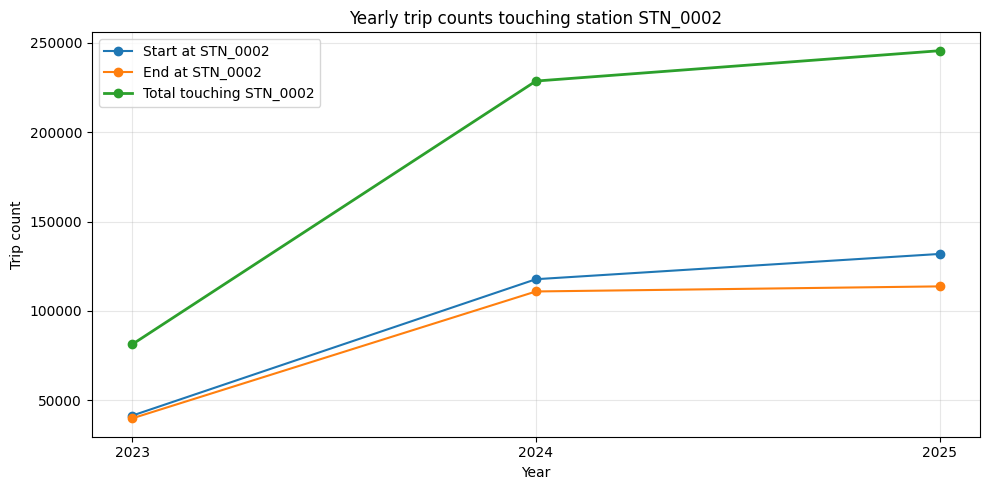

In [7]:
import matplotlib.pyplot as plt

TARGET_STATION = "STN_0002"

station_df = (
    rides_df
    .withColumn("trip_year", F.coalesce(F.col("ride_year"), F.year(F.col("start_time_ms"))))
    .filter(
        (F.col("start_canonical_station_id") == TARGET_STATION)
        | (F.col("end_canonical_station_id") == TARGET_STATION)
    )
    .cache()
)

print(f"Trips touching station {TARGET_STATION}:", f"{station_df.count():,}")

role_counts = (
    station_df
    .select(
        "trip_year",
        F.when(F.col("start_canonical_station_id") == TARGET_STATION, F.lit(1)).otherwise(F.lit(0)).alias("start_hit"),
        F.when(F.col("end_canonical_station_id") == TARGET_STATION, F.lit(1)).otherwise(F.lit(0)).alias("end_hit")
    )
    .groupBy("trip_year")
    .agg(
        F.sum("start_hit").alias("start_count"),
        F.sum("end_hit").alias("end_count")
    )
    .withColumn("total_count", F.col("start_count") + F.col("end_count"))
    .orderBy("trip_year")
)

role_counts_pd = role_counts.toPandas()
print(role_counts_pd)

# Treat year as categorical to show each year as a discrete value on x-axis.
year_labels = role_counts_pd["trip_year"].astype(int).astype(str)

plt.figure(figsize=(10, 5))
plt.plot(year_labels, role_counts_pd["start_count"], marker="o", label=f"Start at {TARGET_STATION}")
plt.plot(year_labels, role_counts_pd["end_count"], marker="o", label=f"End at {TARGET_STATION}")
plt.plot(year_labels, role_counts_pd["total_count"], marker="o", linewidth=2, label=f"Total touching {TARGET_STATION}")
plt.title(f"Yearly trip counts touching station {TARGET_STATION}")
plt.xlabel("Year")
plt.ylabel("Trip count")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Top connection points for STN_0002 by year (first 10 per year):

Year 2023


,station,out_count,in_count,total,year
0,STN_0072,1365,1266,2631,2023
1,STN_0002,1273,1273,2546,2023
2,STN_0005,1198,1318,2516,2023
3,STN_0122,1195,1161,2356,2023
4,STN_0233,943,1142,2085,2023
5,STN_0027,1120,903,2023,2023
6,STN_0001,640,1192,1832,2023
7,STN_0026,909,847,1756,2023
8,STN_0043,761,892,1653,2023
9,STN_0053,791,680,1471,2023



Year 2024


,station,out_count,in_count,total,year
720,STN_0005,5058,4711,9769,2024
721,STN_0002,3441,3441,6882,2024
722,STN_0001,2471,3520,5991,2024
723,STN_0072,2635,2546,5181,2024
724,STN_0122,2733,2152,4885,2024
725,STN_0053,2504,2144,4648,2024
726,STN_0026,2305,2128,4433,2024
727,STN_0043,2131,2270,4401,2024
728,STN_0233,2083,2083,4166,2024
729,STN_0066,2203,1860,4063,2024



Year 2025


,station,out_count,in_count,total,year
1590,STN_0001,3434,4602,8036,2025
1591,STN_0072,3833,3080,6913,2025
1592,STN_0002,3270,3270,6540,2025
1593,STN_0122,3599,2723,6322,2025
1594,STN_0026,3265,2643,5908,2025
1595,STN_0005,2935,2781,5716,2025
1596,STN_0280,3316,2279,5595,2025
1597,STN_0053,3146,2141,5287,2025
1598,STN_0097,2347,1759,4106,2025
1599,STN_0220,2038,1959,3997,2025


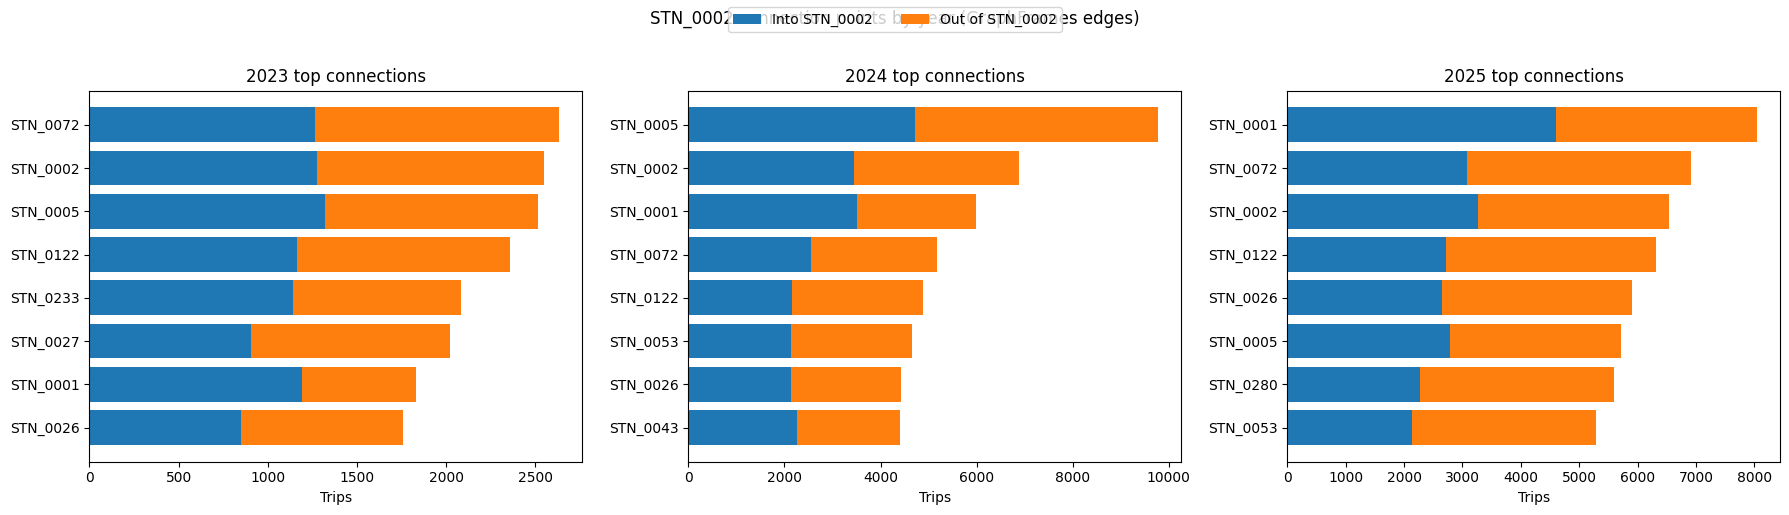

In [8]:
from graphframes import GraphFrame
import pandas as pd

YEARS = [2023, 2024, 2025]

def build_year_graph(year: int):
    year_df = (
        station_df
        .filter(F.col("trip_year") == year)
        .select(
            F.col("start_canonical_station_id").alias("src"),
            F.col("end_canonical_station_id").alias("dst")
        )
        .filter(F.col("src").isNotNull() & F.col("dst").isNotNull())
        .groupBy("src", "dst")
        .agg(F.count("*").alias("trip_count"))
    )

    vertices = (
        year_df.select(F.col("src").alias("id"))
        .union(year_df.select(F.col("dst").alias("id")))
        .distinct()
    )

    return GraphFrame(vertices, year_df)

connection_frames = []

for y in YEARS:
    g = build_year_graph(y)

    out_conn = (
        g.edges
        .filter(F.col("src") == TARGET_STATION)
        .groupBy(F.col("dst").alias("station"))
        .agg(F.sum("trip_count").alias("out_count"))
    )

    in_conn = (
        g.edges
        .filter(F.col("dst") == TARGET_STATION)
        .groupBy(F.col("src").alias("station"))
        .agg(F.sum("trip_count").alias("in_count"))
    )

    joined = (
        out_conn
        .join(in_conn, on="station", how="full")
        .na.fill(0, subset=["out_count", "in_count"])
        .withColumn("total", F.col("out_count") + F.col("in_count"))
        .withColumn("year", F.lit(y))
    )

    connection_frames.append(joined)

connections_all = connection_frames[0]
for part in connection_frames[1:]:
    connections_all = connections_all.unionByName(part)

connections_pd = (
    connections_all
    .orderBy("year", F.desc("total"))
    .toPandas()
)

print(f"Top connection points for {TARGET_STATION} by year (first 10 per year):")
for y in YEARS:
    print(f"\nYear {y}")
    display(connections_pd[connections_pd["year"] == y].head(10))

# Visualize top 8 connection points per year
fig, axes = plt.subplots(1, len(YEARS), figsize=(18, 5), sharex=False)
if len(YEARS) == 1:
    axes = [axes]

for ax, y in zip(axes, YEARS):
    top = connections_pd[connections_pd["year"] == y].nlargest(8, "total")
    if top.empty:
        ax.text(0.5, 0.5, f"No connections\nfor {y}", ha="center", va="center")
        ax.set_title(str(y))
        ax.axis("off")
        continue

    labels = top["station"].astype(str)
    ax.barh(labels, top["in_count"], label=f"Into {TARGET_STATION}")
    ax.barh(labels, top["out_count"], left=top["in_count"], label=f"Out of {TARGET_STATION}")
    ax.invert_yaxis()
    ax.set_title(f"{y} top connections")
    ax.set_xlabel("Trips")

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=2)

fig.suptitle(f"{TARGET_STATION} connection points by year (GraphFrames edges)", y=1.02)
plt.tight_layout()
plt.show()

## 2023-2024 Driver Exploration (Inflow vs Outflow)

Objective: Identify the main drivers behind inflow and outflow at `TARGET_STATION` using 2023-2024 trips.

Plan:
1. Build a direction-aware analysis table (`inflow` / `outflow`) and summarize yearly volumes.
2. Quantify network drivers: top counterpart stations and concentration share.
3. Quantify temporal drivers: monthly, weekday, and hourly patterns, then compare inflow vs outflow.

In [9]:
import pandas as pd
import numpy as np

ANALYSIS_YEARS = [2023, 2024]

base_2023_2024 = (
    rides_df
    .filter(F.col("ride_year").isin(ANALYSIS_YEARS))
    .withColumn("trip_year", F.col("ride_year"))
)

outflow_df = (
    base_2023_2024
    .filter(F.col("start_canonical_station_id") == TARGET_STATION)
    .select(
        "trip_year",
        F.col("start_time_ms").alias("event_ts"),
        F.lit("outflow").alias("direction"),
        F.col("end_canonical_station_id").alias("counterpart_station")
    )
)

inflow_df = (
    base_2023_2024
    .filter(F.col("end_canonical_station_id") == TARGET_STATION)
    .select(
        "trip_year",
        F.col("end_time_ms").alias("event_ts"),
        F.lit("inflow").alias("direction"),
        F.col("start_canonical_station_id").alias("counterpart_station")
    )
)

flow_df = (
    outflow_df
    .unionByName(inflow_df)
    .filter(F.col("counterpart_station").isNotNull())
    .withColumn("month", F.month("event_ts"))
    .withColumn("day_of_week", F.date_format("event_ts", "E"))
    .withColumn("hour", F.hour("event_ts"))
    .cache()
)

annual_direction = (
    flow_df
    .groupBy("trip_year", "direction")
    .agg(F.count("*").alias("trip_count"))
    .orderBy("trip_year", "direction")
)

annual_direction_pd = annual_direction.toPandas()
print("2023-2024 inflow/outflow totals")
print(annual_direction_pd)

pivot_annual = (
    annual_direction_pd
    .pivot(index="trip_year", columns="direction", values="trip_count")
    .fillna(0)
    .astype(int)
)
pivot_annual["total"] = pivot_annual.sum(axis=1)
print("\nAnnual totals table")
print(pivot_annual)

if len(pivot_annual.index) >= 2:
    years_sorted = sorted(pivot_annual.index.tolist())
    y0, y1 = years_sorted[0], years_sorted[1]
    for c in ["inflow", "outflow", "total"]:
        if c in pivot_annual.columns and pivot_annual.loc[y0, c] > 0:
            growth = (pivot_annual.loc[y1, c] / pivot_annual.loc[y0, c]) - 1
            print(f"{c} growth {y0}->{y1}: {growth:.1%}")

2023-2024 inflow/outflow totals
   trip_year direction  trip_count
0       2023    inflow       39849
1       2023   outflow       41256
2       2024    inflow      110865
3       2024   outflow      117231

Annual totals table
direction  inflow  outflow   total
trip_year                         
2023        39849    41256   81105
2024       110865   117231  228096
inflow growth 2023->2024: 178.2%
outflow growth 2023->2024: 184.2%
total growth 2023->2024: 181.2%


Top counterpart stations by year and direction (first rows):
    trip_year direction counterpart_station  trip_count  rank  total_in_group  \
0        2023    inflow            STN_0005        1318     1           39849   
1        2023    inflow            STN_0002        1273     2           39849   
2        2023    inflow            STN_0072        1266     3           39849   
3        2023    inflow            STN_0001        1192     4           39849   
4        2023    inflow            STN_0122        1161     5           39849   
5        2023    inflow            STN_0233        1142     6           39849   
6        2023    inflow            STN_0027         903     7           39849   
7        2023    inflow            STN_0043         892     8           39849   
8        2023    inflow            STN_0026         847     9           39849   
9        2023    inflow            STN_0053         680    10           39849   
10       2023    inflow            STN_0238     

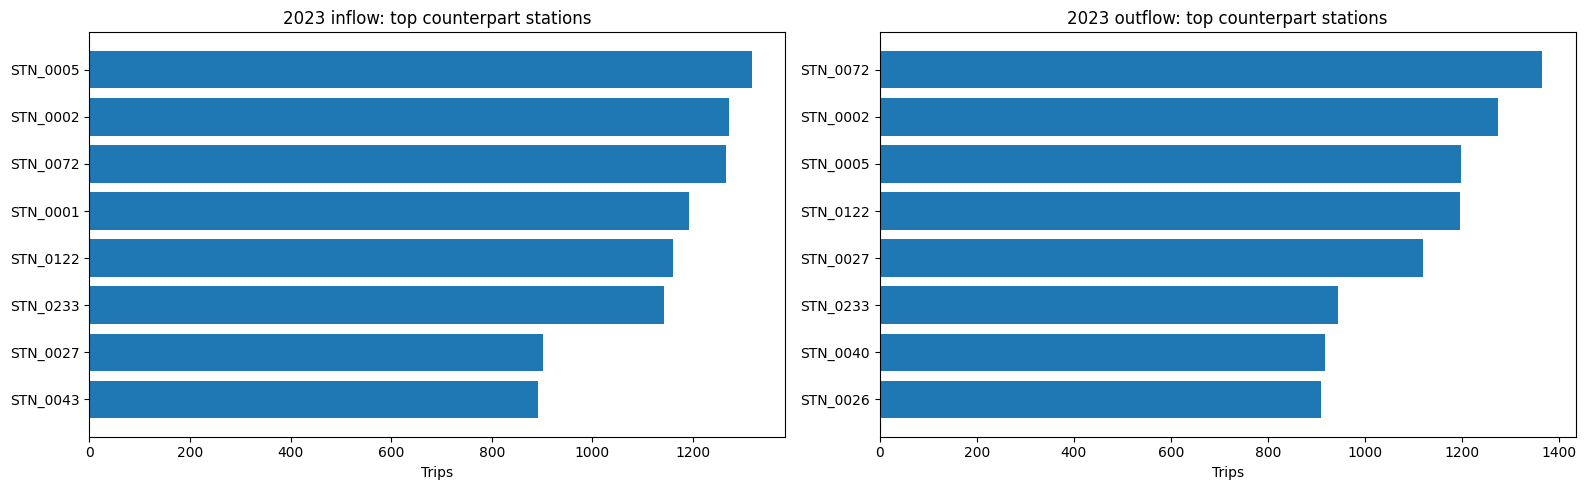

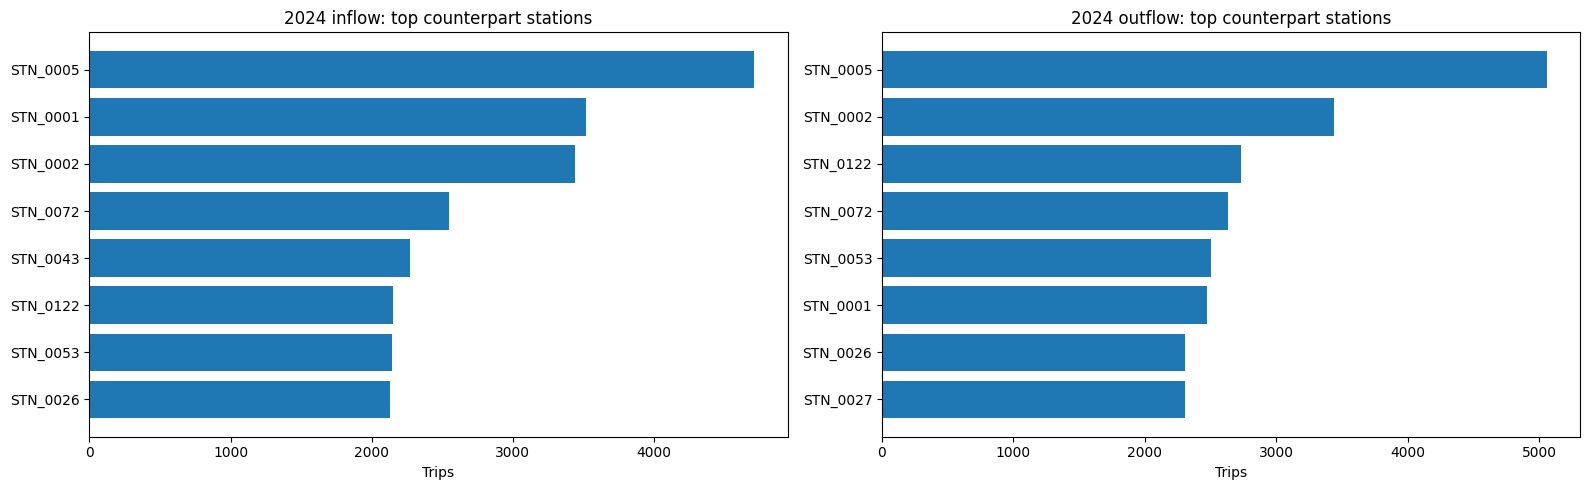

In [10]:
# Task 2: Network drivers (which counterpart stations drive volume)
TOP_N = 12

counterpart_year = (
    flow_df
    .groupBy("trip_year", "direction", "counterpart_station")
    .agg(F.count("*").alias("trip_count"))
)

window_y_d = __import__("pyspark").sql.Window.partitionBy("trip_year", "direction").orderBy(F.desc("trip_count"))
total_y_d = __import__("pyspark").sql.Window.partitionBy("trip_year", "direction")

counterpart_ranked = (
    counterpart_year
    .withColumn("rank", F.row_number().over(window_y_d))
    .withColumn("total_in_group", F.sum("trip_count").over(total_y_d))
    .withColumn("share", F.col("trip_count") / F.col("total_in_group"))
)

counterpart_top_pd = (
    counterpart_ranked
    .filter(F.col("rank") <= TOP_N)
    .orderBy("trip_year", "direction", "rank")
    .toPandas()
)

driver_concentration_pd = (
    counterpart_ranked
    .groupBy("trip_year", "direction")
    .agg(
        F.sum(F.when(F.col("rank") <= 5, F.col("trip_count")).otherwise(F.lit(0))).alias("top5_trips"),
        F.max("total_in_group").alias("total_trips")
    )
    .withColumn("top5_share", F.col("top5_trips") / F.col("total_trips"))
    .orderBy("trip_year", "direction")
    .toPandas()
)

print("Top counterpart stations by year and direction (first rows):")
print(counterpart_top_pd.head(20))

print("\nConcentration of drivers (Top-5 share):")
print(driver_concentration_pd)

# Visual: top-8 counterpart stations in each year/direction panel
for y in ANALYSIS_YEARS:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=False)
    for ax, d in zip(axes, ["inflow", "outflow"]):
        sub = counterpart_top_pd[(counterpart_top_pd["trip_year"] == y) & (counterpart_top_pd["direction"] == d)].head(8)
        ax.barh(sub["counterpart_station"], sub["trip_count"])
        ax.invert_yaxis()
        ax.set_title(f"{y} {d}: top counterpart stations")
        ax.set_xlabel("Trips")
    plt.tight_layout()
    plt.show()

Peak-hour share metrics (7-9 and 16-18):
   trip_year direction  total_trips  am_peak_trips  pm_peak_trips  \
0       2023    inflow        39849           5369           9700   
1       2023   outflow        41256           3775          11079   
2       2024    inflow       110865          13760          28485   
3       2024   outflow       117231          10965          32383   

   am_peak_share  pm_peak_share  
0       0.134734       0.243419  
1       0.091502       0.268543  
2       0.124115       0.256934  
3       0.093533       0.276232  


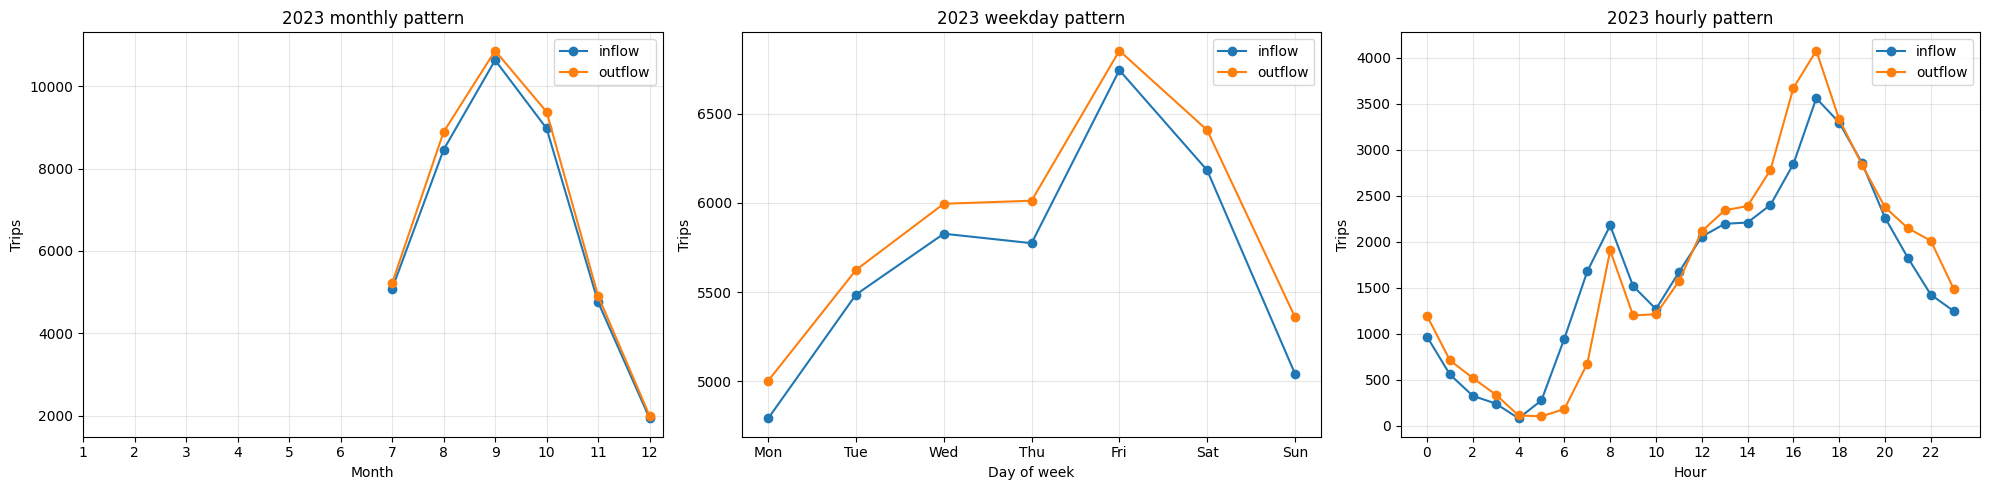

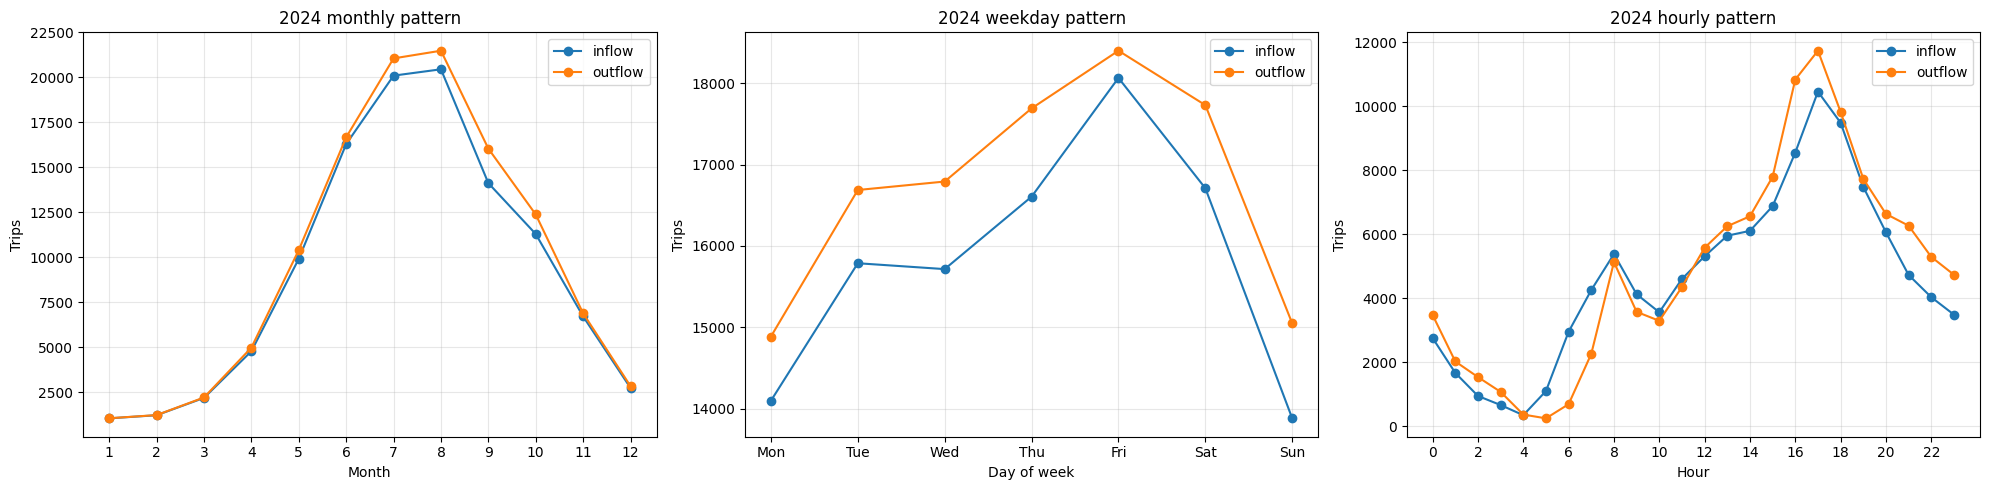


Largest monthly absolute changes (2024 vs 2023):
trip_year           2023     2024  abs_change_2024_vs_2023  \
direction month                                              
outflow   6          0.0  16671.0                  16671.0   
inflow    6          0.0  16293.0                  16293.0   
outflow   7       5218.0  21056.0                  15838.0   
inflow    7       5085.0  20098.0                  15013.0   
outflow   8       8893.0  21483.0                  12590.0   
inflow    8       8461.0  20450.0                  11989.0   
outflow   5          0.0  10404.0                  10404.0   
inflow    5          0.0   9917.0                   9917.0   
outflow   9      10864.0  16042.0                   5178.0   
          4          0.0   4979.0                   4979.0   
inflow    4          0.0   4780.0                   4780.0   
          9      10635.0  14124.0                   3489.0   

trip_year        pct_change_2024_vs_2023  
direction month                       

In [11]:
# Task 3: Temporal drivers (seasonality and commuting profile)
dow_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

monthly_pd = (
    flow_df
    .groupBy("trip_year", "direction", "month")
    .agg(F.count("*").alias("trip_count"))
    .orderBy("trip_year", "direction", "month")
    .toPandas()
)

weekday_pd = (
    flow_df
    .groupBy("trip_year", "direction", "day_of_week")
    .agg(F.count("*").alias("trip_count"))
    .toPandas()
)
weekday_pd["day_of_week"] = pd.Categorical(weekday_pd["day_of_week"], categories=dow_order, ordered=True)
weekday_pd = weekday_pd.sort_values(["trip_year", "direction", "day_of_week"])

hourly_pd = (
    flow_df
    .groupBy("trip_year", "direction", "hour")
    .agg(F.count("*").alias("trip_count"))
    .orderBy("trip_year", "direction", "hour")
    .toPandas()
)

# Peak-hour share as a compact "driver" metric
peak_metrics_pd = (
    flow_df
    .withColumn("is_am_peak", F.col("hour").between(7, 9).cast("int"))
    .withColumn("is_pm_peak", F.col("hour").between(16, 18).cast("int"))
    .groupBy("trip_year", "direction")
    .agg(
        F.count("*").alias("total_trips"),
        F.sum("is_am_peak").alias("am_peak_trips"),
        F.sum("is_pm_peak").alias("pm_peak_trips")
    )
    .withColumn("am_peak_share", F.col("am_peak_trips") / F.col("total_trips"))
    .withColumn("pm_peak_share", F.col("pm_peak_trips") / F.col("total_trips"))
    .orderBy("trip_year", "direction")
    .toPandas()
)

print("Peak-hour share metrics (7-9 and 16-18):")
print(peak_metrics_pd)

for y in ANALYSIS_YEARS:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    m = monthly_pd[monthly_pd["trip_year"] == y]
    for d in ["inflow", "outflow"]:
        md = m[m["direction"] == d]
        axes[0].plot(md["month"], md["trip_count"], marker="o", label=d)
    axes[0].set_title(f"{y} monthly pattern")
    axes[0].set_xlabel("Month")
    axes[0].set_ylabel("Trips")
    axes[0].set_xticks(range(1, 13))
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    w = weekday_pd[weekday_pd["trip_year"] == y]
    for d in ["inflow", "outflow"]:
        wd = w[w["direction"] == d]
        axes[1].plot(wd["day_of_week"].astype(str), wd["trip_count"], marker="o", label=d)
    axes[1].set_title(f"{y} weekday pattern")
    axes[1].set_xlabel("Day of week")
    axes[1].set_ylabel("Trips")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    h = hourly_pd[hourly_pd["trip_year"] == y]
    for d in ["inflow", "outflow"]:
        hd = h[h["direction"] == d]
        axes[2].plot(hd["hour"], hd["trip_count"], marker="o", label=d)
    axes[2].set_title(f"{y} hourly pattern")
    axes[2].set_xlabel("Hour")
    axes[2].set_ylabel("Trips")
    axes[2].set_xticks(range(0, 24, 2))
    axes[2].grid(alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

# Year-over-year change by month to surface strongest seasonal drivers
monthly_pivot = (
    monthly_pd
    .pivot_table(index=["direction", "month"], columns="trip_year", values="trip_count", aggfunc="sum")
    .fillna(0)
)
if 2023 in monthly_pivot.columns and 2024 in monthly_pivot.columns:
    monthly_pivot["abs_change_2024_vs_2023"] = monthly_pivot[2024] - monthly_pivot[2023]
    monthly_pivot["pct_change_2024_vs_2023"] = np.where(
        monthly_pivot[2023] > 0,
        (monthly_pivot[2024] / monthly_pivot[2023]) - 1,
        np.nan
    )
    print("\nLargest monthly absolute changes (2024 vs 2023):")
    print(monthly_pivot.sort_values("abs_change_2024_vs_2023", ascending=False).head(12))

Monthly coverage-adjusted view (first rows):
    trip_year direction  month  trip_count  active_days  trips_per_active_day
0        2023    inflow      7        5085           26            195.576923
1        2023    inflow      8        8461           31            272.935484
2        2023    inflow      9       10635           30            354.500000
3        2023    inflow     10        8975           30            299.166667
4        2023    inflow     11        4757           30            158.566667
5        2023    inflow     12        1936           31             62.451613
6        2023   outflow      7        5218           26            200.692308
7        2023   outflow      8        8893           31            286.870968
8        2023   outflow      9       10864           30            362.133333
9        2023   outflow     10        9378           30            312.600000
10       2023   outflow     11        4909           30            163.633333
11       2023   out

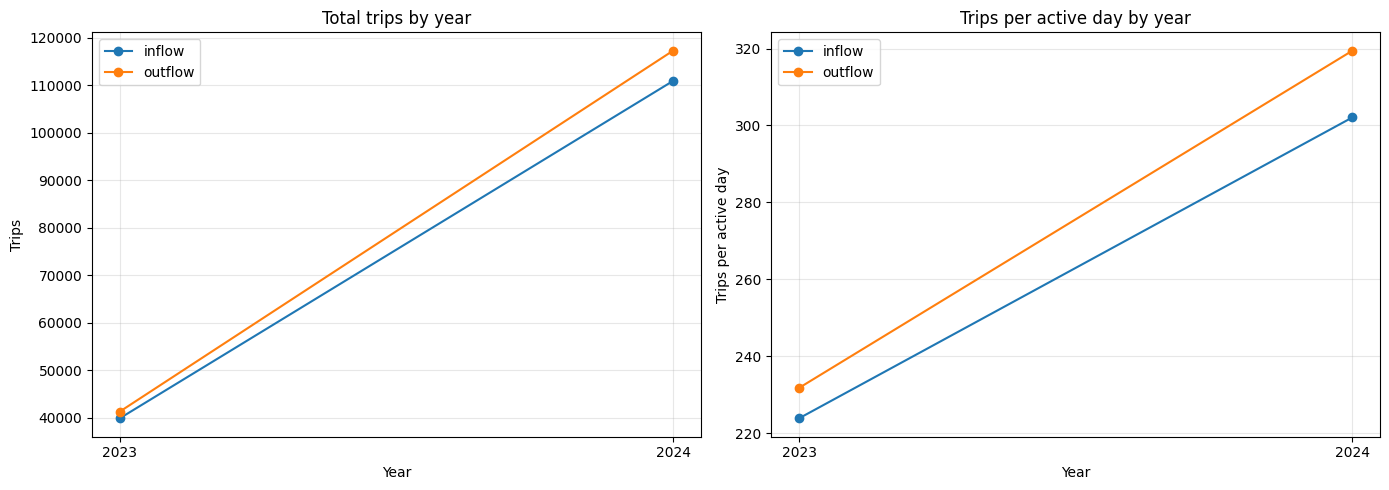

In [12]:
# Task 4: Coverage check (active days) to avoid mistaking partial data for demand shifts
coverage_pd = (
    flow_df
    .withColumn("event_date", F.to_date("event_ts"))
    .groupBy("trip_year", "direction", "month")
    .agg(
        F.count("*").alias("trip_count"),
        F.countDistinct("event_date").alias("active_days")
    )
    .withColumn("trips_per_active_day", F.col("trip_count") / F.col("active_days"))
    .orderBy("trip_year", "direction", "month")
    .toPandas()
)

print("Monthly coverage-adjusted view (first rows):")
print(coverage_pd.head(18))

year_cov_pd = (
    coverage_pd
    .groupby(["trip_year", "direction"], as_index=False)
    .agg(
        trip_count=("trip_count", "sum"),
        active_days=("active_days", "sum")
    )
)
year_cov_pd["trips_per_active_day"] = year_cov_pd["trip_count"] / year_cov_pd["active_days"]
print("\nYear-level coverage-adjusted summary:")
print(year_cov_pd)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for d in ["inflow", "outflow"]:
    sub = year_cov_pd[year_cov_pd["direction"] == d]
    axes[0].plot(sub["trip_year"].astype(str), sub["trip_count"], marker="o", label=d)
    axes[1].plot(sub["trip_year"].astype(str), sub["trips_per_active_day"], marker="o", label=d)

axes[0].set_title("Total trips by year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Trips")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title("Trips per active day by year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Trips per active day")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Missing-Mapping Investigation Around TARGET_STATION

Objective: Find whether another canonical station appears to have absorbed `TARGET_STATION` trips during the suspected missing period.

Plan:
1. Use `data/silver/station_cleaning` canonical metadata to find stations most similar by location and station name.
2. Build monthly station-touch counts from rides (start+end) and check whether candidates fill months where target is missing.
3. Test if each candidate shows a post Jun/Jul drop (2023) while target rises, then rank best replacement candidates.

In [23]:
# Task 1: Find geo/name-similar stations from station_cleaning metadata
from difflib import SequenceMatcher
import numpy as np

station_cleaning_root = "data/silver/station_cleaning"
station_summary_path = f"{station_cleaning_root}/station_canonical_summary"
station_mapping_path = f"{station_cleaning_root}/station_direct_match_mapping"

station_summary_df = spark.read.parquet(station_summary_path)
print("station_canonical_summary columns:")
print(station_summary_df.columns)

# station_canonical_summary has stable coordinates per canonical ID
station_meta_pd = (
    station_summary_df
    .select(
        F.col("canonical_station_id").alias("station_id"),
        F.col("canonical_lat").alias("lat"),
        F.col("canonical_lon").alias("lon")
    )
    .dropDuplicates(["station_id"])
    .toPandas()
)

# Pull representative names from direct mapping table (if available)
mapping_df = spark.read.parquet(station_mapping_path)
print("station_direct_match_mapping columns:")
print(mapping_df.columns)

candidate_name_cols = [
    "normalized_name",
    "canonical_station_name_norm",
    "canonical_name_norm",
    "station_name_norm",
    "canonical_station_name",
    "canonical_name",
    "station_name",
]
available_name_cols = [c for c in candidate_name_cols if c in mapping_df.columns]

if "canonical_station_id" in mapping_df.columns and available_name_cols:
    name_exprs = [F.first(F.col(c), ignorenulls=True).alias(c) for c in available_name_cols]
    name_df = mapping_df.groupBy("canonical_station_id").agg(*name_exprs)
    name_pd = name_df.toPandas().rename(columns={"canonical_station_id": "station_id"})
else:
    name_pd = station_meta_pd[["station_id"]].copy()

station_meta_pd = station_meta_pd.merge(name_pd, on="station_id", how="left")

# Select best available text fields
name_norm_col = next((c for c in ["normalized_name", "canonical_station_name_norm", "canonical_name_norm", "station_name_norm"] if c in station_meta_pd.columns), None)
name_col = next((c for c in ["canonical_station_name", "canonical_name", "station_name"] if c in station_meta_pd.columns), None)

if name_col is None:
    station_meta_pd["name"] = station_meta_pd["station_id"]
else:
    station_meta_pd["name"] = station_meta_pd[name_col]

if name_norm_col is None:
    station_meta_pd["name_norm"] = station_meta_pd["name"].astype(str).str.lower().str.strip()
else:
    station_meta_pd["name_norm"] = station_meta_pd[name_norm_col].astype(str).str.lower().str.strip()

station_meta_pd = station_meta_pd.dropna(subset=["station_id", "lat", "lon"]).copy()
station_meta_pd["station_id"] = station_meta_pd["station_id"].astype(str)

target_meta = station_meta_pd[station_meta_pd["station_id"] == TARGET_STATION]
if target_meta.empty:
    raise RuntimeError(f"TARGET_STATION={TARGET_STATION} not found in station metadata")

t = target_meta.iloc[0]

# Great-circle distance in km
r_earth = 6371.0
lat1 = np.radians(float(t["lat"]))
lon1 = np.radians(float(t["lon"]))
lat2 = np.radians(station_meta_pd["lat"].astype(float))
lon2 = np.radians(station_meta_pd["lon"].astype(float))
dlat = lat2 - lat1
dlon = lon2 - lon1
a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * (np.sin(dlon / 2) ** 2)
station_meta_pd["distance_km"] = 2 * r_earth * np.arcsin(np.sqrt(a))

target_name_norm = str(t.get("name_norm") or "").lower().strip()

def text_sim(s):
    s = str(s or "").lower().strip()
    if not target_name_norm or not s or s == "none":
        return 0.0
    return SequenceMatcher(None, target_name_norm, s).ratio()

station_meta_pd["name_similarity"] = station_meta_pd["name_norm"].apply(text_sim)
station_meta_pd["geo_similarity"] = 1.0 / (1.0 + station_meta_pd["distance_km"])
station_meta_pd["similarity_score"] = 0.75 * station_meta_pd["geo_similarity"] + 0.25 * station_meta_pd["name_similarity"]

candidate_ranked_geo_name = (
    station_meta_pd[station_meta_pd["station_id"] != TARGET_STATION]
    .sort_values(["similarity_score", "distance_km", "name_similarity"], ascending=[False, True, False])
    .reset_index(drop=True)
)

print(f"Target station metadata for {TARGET_STATION}:")
print(t[[c for c in ["station_id", "name", "name_norm", "lat", "lon"] if c in t.index]])

print("\nTop 15 geo+name similar stations:")
print(candidate_ranked_geo_name[["station_id", "name", "name_norm", "distance_km", "name_similarity", "similarity_score"]].head(15))

station_canonical_summary columns:
['canonical_station_id', 'canonical_coord_key', 'canonical_lat', 'canonical_lon', 'cluster_size', 'canonical_total_trips', 'member_coord_count', 'member_name_count', 'first_year_seen', 'last_year_seen']
station_direct_match_mapping columns:
['station_key', 'coord_key', 'normalized_name', 'canonical_station_id', 'canonical_coord_key', 'canonical_lat', 'canonical_lon', 'cluster_id', 'cluster_size', 'observed_trip_count', 'first_year_seen', 'last_year_seen']
Target station metadata for STN_0002:
station_id                                          STN_0002
name                                                STN_0002
name_norm     métro mont-royal (utilités publiques / rivard)
lat                                                45.524236
lon                                               -73.581552
Name: 1232, dtype: object

Top 15 geo+name similar stations:
   station_id      name                                   name_norm  \
0    STN_0948  STN_0948       

## Missing-Mapping Investigation Around TARGET_STATION

Objective: Find whether another canonical station appears to have absorbed `TARGET_STATION` trips during the suspected missing period.

Plan:
1. Use `data/silver/station_cleaning` canonical metadata to find stations most similar by location and station name.
2. Build monthly station-touch counts from rides (start+end) and check whether candidates fill months where target is missing.
3. Test if each candidate shows a post Jun/Jul drop (2023) while target rises, then rank best replacement candidates.

Target missing months in 2023: [1, 2, 3, 4, 5, 6]


Top 15 candidates for potential missing mapping handoff:
   station_id  pre_jan_jun_2023  post_jul_dec_2023  gap_fill_jan_to_gap  \
0    STN_0652           37043.0                0.0              37043.0   
1    STN_0001           47781.0            95580.0              47781.0   
2    STN_0013           42403.0            83957.0              42403.0   
3    STN_1091            6683.0                0.0               6683.0   
4    STN_0143           30893.0            46141.0              30893.0   
5    STN_0027           32981.0            62821.0              32981.0   
6    STN_0014           31708.0            63845.0              31708.0   
7    STN_0029           31942.0            58922.0              31942.0   
8    STN_0414           30209.0            37839.0              30209.0   
9    STN_0046           27461.0            46475.0              27461.0   
10   STN_0038           28529.0            42175.0              28529.0   
11   STN_0030           29404.0            

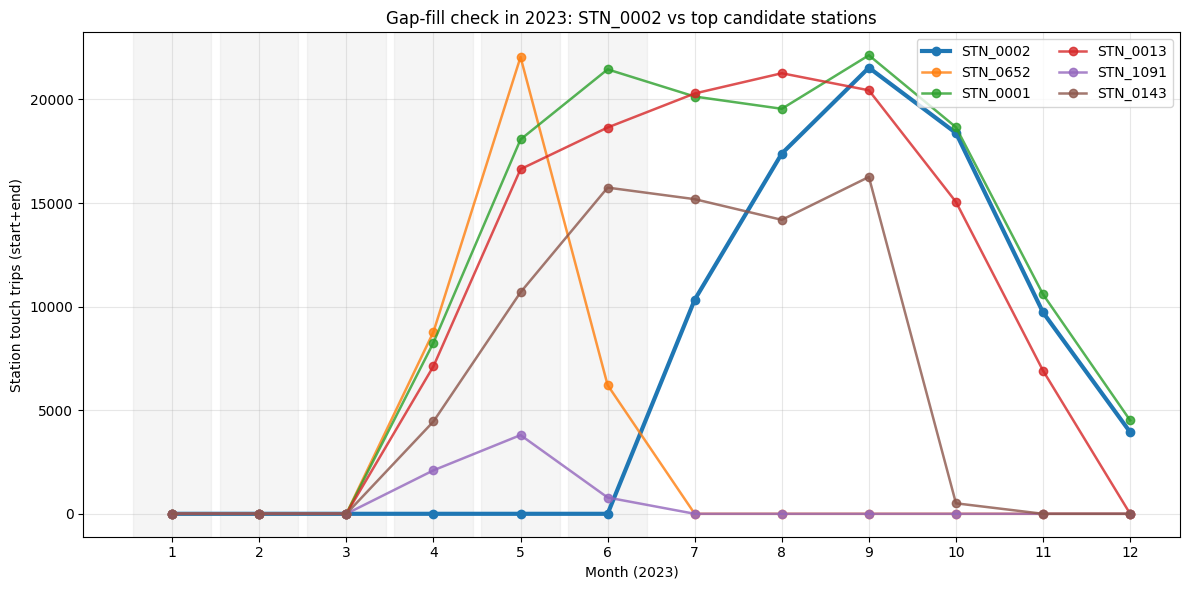

In [21]:
# Task 2: Check gap-fill behavior and post Jun/Jul drop for similar stations
from pyspark.sql import Window

# Build monthly station-touch counts (start+end) for 2023-2024
all_out = (
    rides_df
    .filter(F.col("ride_year").isin([2023, 2024]))
    .select(
        F.col("ride_year").alias("trip_year"),
        F.month("start_time_ms").alias("month"),
        F.col("start_canonical_station_id").alias("station_id")
    )
)

all_in = (
    rides_df
    .filter(F.col("ride_year").isin([2023, 2024]))
    .select(
        F.col("ride_year").alias("trip_year"),
        F.month("end_time_ms").alias("month"),
        F.col("end_canonical_station_id").alias("station_id")
    )
)

all_station_month = (
    all_out
    .unionByName(all_in)
    .filter(F.col("station_id").isNotNull())
    .groupBy("trip_year", "month", "station_id")
    .agg(F.count("*").alias("touch_trips"))
)

# Detect target missing months in 2023 explicitly against all 12 months
target_2023_pd = (
    all_station_month
    .filter((F.col("trip_year") == 2023) & (F.col("station_id") == TARGET_STATION))
    .select("month", "touch_trips")
    .toPandas()
)

target_2023_series = pd.Series(0, index=range(1, 13), dtype=float)
if not target_2023_pd.empty:
    target_2023_series.loc[target_2023_pd["month"].astype(int).tolist()] = target_2023_pd["touch_trips"].tolist()

gap_months = [m for m in range(1, 13) if target_2023_series.loc[m] == 0]
print(f"Target missing months in 2023: {gap_months}")

candidate_ids = candidate_ranked_geo_name["station_id"].head(80).tolist()
if TARGET_STATION in candidate_ids:
    candidate_ids.remove(TARGET_STATION)

cand_month_pd = (
    all_station_month
    .filter((F.col("trip_year") == 2023) & F.col("station_id").isin(candidate_ids + [TARGET_STATION]))
    .toPandas()
)

# Complete month grid for stable comparisons
rows = []
for sid in candidate_ids + [TARGET_STATION]:
    sub = cand_month_pd[cand_month_pd["station_id"] == sid]
    month_map = dict(zip(sub["month"].astype(int), sub["touch_trips"].astype(float)))
    for m in range(1, 13):
        rows.append({"station_id": sid, "month": m, "touch_trips": month_map.get(m, 0.0)})
full_2023_pd = pd.DataFrame(rows)

# Score candidate on gap fill + post-gap drop + geo/name similarity
sim_lookup = candidate_ranked_geo_name.set_index("station_id")
score_rows = []
for sid in candidate_ids:
    s = full_2023_pd[full_2023_pd["station_id"] == sid].set_index("month")["touch_trips"]
    pre = float(s.loc[[m for m in range(1, 7)]].sum())
    post = float(s.loc[[m for m in range(7, 13)]].sum())
    gap_fill = float(s.loc[gap_months].sum()) if gap_months else 0.0

    if pre > 0:
        drop_ratio = (pre - post) / pre  # positive => drop after Jun
    else:
        drop_ratio = np.nan

    sim_score = float(sim_lookup.loc[sid, "similarity_score"]) if sid in sim_lookup.index else 0.0

    score_rows.append({
        "station_id": sid,
        "pre_jan_jun_2023": pre,
        "post_jul_dec_2023": post,
        "gap_fill_jan_to_gap": gap_fill,
        "post_drop_ratio": drop_ratio,
        "similarity_score": sim_score,
    })

candidate_gap_pd = pd.DataFrame(score_rows)
if candidate_gap_pd.empty:
    raise RuntimeError("No candidate stations available for gap analysis.")

candidate_gap_pd["gap_fill_norm"] = candidate_gap_pd["gap_fill_jan_to_gap"] / max(candidate_gap_pd["gap_fill_jan_to_gap"].max(), 1.0)
candidate_gap_pd["drop_score"] = candidate_gap_pd["post_drop_ratio"].fillna(-1).clip(lower=0, upper=1)
candidate_gap_pd["sim_norm"] = candidate_gap_pd["similarity_score"] / max(candidate_gap_pd["similarity_score"].max(), 1.0)
candidate_gap_pd["gap_candidate_score"] = (
    0.50 * candidate_gap_pd["gap_fill_norm"]
    + 0.30 * candidate_gap_pd["drop_score"]
    + 0.20 * candidate_gap_pd["sim_norm"]
)

candidate_gap_ranked = candidate_gap_pd.sort_values(
    ["gap_candidate_score", "gap_fill_jan_to_gap", "post_drop_ratio"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("Top 15 candidates for potential missing mapping handoff:")
print(candidate_gap_ranked.head(15))

best_candidate = candidate_gap_ranked.iloc[0]["station_id"]
print(f"\nBest candidate based on current scoring: {best_candidate}")

# Visual check: target vs top 5 candidates across 2023 months
top5 = candidate_gap_ranked.head(5)["station_id"].tolist()
plot_ids = [TARGET_STATION] + top5
plot_pd = full_2023_pd[full_2023_pd["station_id"].isin(plot_ids)].copy()

plt.figure(figsize=(12, 6))
for sid in plot_ids:
    s = plot_pd[plot_pd["station_id"] == sid]
    lw = 3 if sid == TARGET_STATION else 1.8
    alpha = 1.0 if sid == TARGET_STATION else 0.8
    plt.plot(s["month"], s["touch_trips"], marker="o", linewidth=lw, alpha=alpha, label=sid)

for m in gap_months:
    plt.axvspan(m - 0.45, m + 0.45, color="gray", alpha=0.08)

plt.xticks(range(1, 13))
plt.xlabel("Month (2023)")
plt.ylabel("Station touch trips (start+end)")
plt.title(f"Gap-fill check in 2023: {TARGET_STATION} vs top candidate stations")
plt.legend(ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Handoff validation ranking (higher is stronger evidence):
   station_id  distance_km  name_similarity  cand_h1_2023  cand_h2_2023  \
0    STN_0652     0.122140         0.590909       37043.0           0.0   
1    STN_1091     0.530417         0.333333        6683.0           0.0   
2    STN_0001     0.677003         0.477612       47781.0       95580.0   
3    STN_0013     0.377514         0.358209       42403.0       83957.0   
4    STN_0143     0.155755         0.376812       30893.0       46141.0   
5    STN_0027     0.625361         0.388060       32981.0       62821.0   
6    STN_0014     0.373736         0.266667       31708.0       63845.0   
7    STN_0029     0.633095         0.333333       31942.0       58922.0   
8    STN_0414     0.694664         0.441558       30209.0       37839.0   
9    STN_0046     0.205903         0.276923       27461.0       46475.0   
10   STN_0038     0.325083         0.187500       28529.0       42175.0   
11   STN_0030     0.852349         0.41176

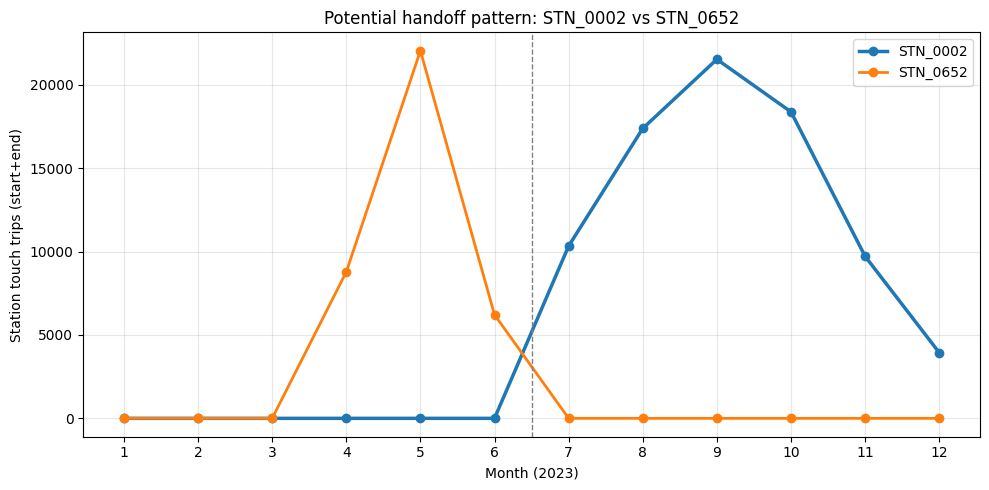

In [22]:
# Task 3: Validate handoff pattern strength for top candidates
# Build 2024 monthly slices for selected stations
cand_top_ids = candidate_gap_ranked.head(12)["station_id"].tolist()
check_ids = cand_top_ids + [TARGET_STATION]

cand_2024_pd = (
    all_station_month
    .filter((F.col("trip_year") == 2024) & F.col("station_id").isin(check_ids))
    .toPandas()
)

rows_2024 = []
for sid in check_ids:
    sub = cand_2024_pd[cand_2024_pd["station_id"] == sid]
    month_map = dict(zip(sub["month"].astype(int), sub["touch_trips"].astype(float)))
    for m in range(1, 13):
        rows_2024.append({"station_id": sid, "month": m, "touch_trips": month_map.get(m, 0.0)})
full_2024_pd = pd.DataFrame(rows_2024)

target_2023 = full_2023_pd[full_2023_pd["station_id"] == TARGET_STATION].set_index("month")["touch_trips"]
target_h1 = float(target_2023.loc[1:6].sum())
target_h2 = float(target_2023.loc[7:12].sum())

handoff_rows = []
for sid in cand_top_ids:
    s23 = full_2023_pd[full_2023_pd["station_id"] == sid].set_index("month")["touch_trips"]
    s24 = full_2024_pd[full_2024_pd["station_id"] == sid].set_index("month")["touch_trips"]

    cand_h1 = float(s23.loc[1:6].sum())
    cand_h2 = float(s23.loc[7:12].sum())
    cand_2024_total = float(s24.sum())

    # Positive when candidate drops after Jun while target rises after Jun
    cand_drop = (cand_h1 - cand_h2) / cand_h1 if cand_h1 > 0 else np.nan
    target_rise = (target_h2 - target_h1) / max(target_h2, 1.0)

    handoff_score = (
        (cand_h1 / max(candidate_gap_ranked["pre_jan_jun_2023"].max(), 1.0))
        * max(cand_drop if not np.isnan(cand_drop) else -1.0, 0)
        * max(target_rise, 0)
    )

    handoff_rows.append({
        "station_id": sid,
        "distance_km": float(sim_lookup.loc[sid, "distance_km"]) if sid in sim_lookup.index else np.nan,
        "name_similarity": float(sim_lookup.loc[sid, "name_similarity"]) if sid in sim_lookup.index else np.nan,
        "cand_h1_2023": cand_h1,
        "cand_h2_2023": cand_h2,
        "cand_drop_ratio_h2_vs_h1": cand_drop,
        "cand_2024_total": cand_2024_total,
        "handoff_score": handoff_score,
    })

handoff_pd = pd.DataFrame(handoff_rows).sort_values("handoff_score", ascending=False).reset_index(drop=True)
print("Handoff validation ranking (higher is stronger evidence):")
print(handoff_pd.head(12))

best_handoff_station = handoff_pd.iloc[0]["station_id"]
print(f"\nBest handoff candidate: {best_handoff_station}")

# Plot 2023 monthly comparison for target + best handoff candidate
compare_ids = [TARGET_STATION, best_handoff_station]
plt.figure(figsize=(10, 5))
for sid in compare_ids:
    s = full_2023_pd[full_2023_pd["station_id"] == sid]
    plt.plot(s["month"], s["touch_trips"], marker="o", linewidth=2.5 if sid == TARGET_STATION else 2.0, label=sid)

plt.axvline(6.5, color="gray", linestyle="--", linewidth=1)
plt.xticks(range(1, 13))
plt.xlabel("Month (2023)")
plt.ylabel("Station touch trips (start+end)")
plt.title(f"Potential handoff pattern: {TARGET_STATION} vs {best_handoff_station}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Station Lookup Within 40m Radius

Objective: Return all canonical stations within 40 meters of `(45.524557, -73.581817)`.

Plan:
1. Read canonical station coordinates from `data/silver/station_cleaning/station_canonical_summary`.
2. Compute great-circle distance in meters.
3. Filter stations where distance is `<= 40m` and display sorted results.

In [107]:
# Task: find all stations in a 40m radius from the given coordinate
lookup_lat, lookup_lon = 45.524236, -73.581552
radius_m = 150.0

# lookup_lat, lookup_lon = 45.52755664225462, -73.58889662657887
# radius_m = 120.0

# lookup_lat, lookup_lon = 45.524236,-73.581552
# radius_m = 200.0

summary_path = "data/silver/station_cleaning/station_canonical_summary"
mapping_path = "data/silver/station_cleaning/station_direct_match_mapping"

summary_df = spark.read.parquet(summary_path)

stations_base = (
    summary_df
    .select(
        F.col("canonical_station_id").alias("station_id"),
        F.col("canonical_lat").cast("double").alias("lat"),
        F.col("canonical_lon").cast("double").alias("lon")
    )
    .dropna(subset=["station_id", "lat", "lon"])
    .dropDuplicates(["station_id"])
)

# Attach a representative normalized name when available.
mapping_df = spark.read.parquet(mapping_path)
if "normalized_name" in mapping_df.columns:
    names_df = (
        mapping_df
        .groupBy("canonical_station_id")
        .agg(F.first("normalized_name", ignorenulls=True).alias("normalized_name"))
        .withColumnRenamed("canonical_station_id", "station_id")
    )
    stations_base = stations_base.join(names_df, on="station_id", how="left")
else:
    stations_base = stations_base.withColumn("normalized_name", F.lit(None).cast("string"))

# Haversine distance in meters.
R = 6371000.0
lat1 = F.radians(F.lit(lookup_lat))
lon1 = F.radians(F.lit(lookup_lon))
lat2 = F.radians(F.col("lat"))
lon2 = F.radians(F.col("lon"))
dlat = lat2 - lat1
dlon = lon2 - lon1

a = F.pow(F.sin(dlat / 2.0), 2) + F.cos(lat1) * F.cos(lat2) * F.pow(F.sin(dlon / 2.0), 2)
# Guard against tiny floating errors that can push a above 1.
distance_m = F.lit(2.0 * R) * F.asin(F.sqrt(F.least(F.lit(1.0), a)))

stations_radius = (
    stations_base
    .withColumn("distance_m", distance_m)
    .filter(F.col("distance_m") <= F.lit(radius_m))
    .orderBy("distance_m", "station_id")
)

stations_radius_pd = stations_radius.toPandas()
print(f"Stations within {radius_m:.0f}m of ({lookup_lat}, {lookup_lon}): {len(stations_radius_pd)}")
display(stations_radius_pd)

stations_radius_pd = stations_radius_pd.drop([2,3,6]) # STN_0002

print(stations_radius_pd.to_markdown())

Stations within 150m of (45.524236, -73.581552): 7


,station_id,lat,lon,normalized_name,distance_m
0,STN_0002,45.524236,-73.581552,métro mont-royal (utilités publiques / rivard),0.000000
1,STN_0948,45.524420,-73.581663,métro mont-royal (place gérald-godin),22.212214
2,STN_0467,45.524559,-73.582633,rivard / du mont-royal,91.552995
3,STN_0859,45.524608,-73.582667,rivard / mont-royal,96.208870
4,STN_0389,45.525014,-73.582209,métro mont-royal (berri / mont-royal),100.516545
5,STN_0652,45.523984,-73.583078,métro mont-royal (pontiac / du mont-royal),122.139504
6,STN_0729,45.523877,-73.583049,mont-royal / st-denis,123.265443


|    | station_id   |     lat |      lon | normalized_name                                |   distance_m |
|---:|:-------------|--------:|---------:|:-----------------------------------------------|-------------:|
|  0 | STN_0002     | 45.5242 | -73.5816 | métro mont-royal (utilités publiques / rivard) |       0      |
|  1 | STN_0948     | 45.5244 | -73.5817 | métro mont-royal (place gérald-godin)          |      22.2122 |
|  4 | STN_0389     | 45.525  | -73.5822 | métro mont-royal (berri / mont-royal)          |     100.517  |
|  5 | STN_0652     | 45.524  | -73.5831 | métro mont-royal (pontiac / du mont-royal)     |     122.14   |


## 2023 Ride Stats For 5 Stations (Within 100m)

Objective: Plot 2023 ride activity for 5 shortlisted stations from the 100m-radius candidate set.

Plan:
1. Use the 100m radius lookup output and pick 5 station IDs (nearest 5 by default).
2. Build monthly ride-touch stats (start + end) for 2023.
3. Plot monthly trends and yearly totals for the 5 stations.

Selected 5 stations: ['STN_0002', 'STN_0948', 'STN_0389', 'STN_0652']



Totals across all available data (start+end touches):
  station_id  total_touch_trips_all_data
0   STN_0002                      555441
1   STN_0389                       72499
2   STN_0652                       37043
3   STN_0948                       13507

Total across selected stations (all data): 678490


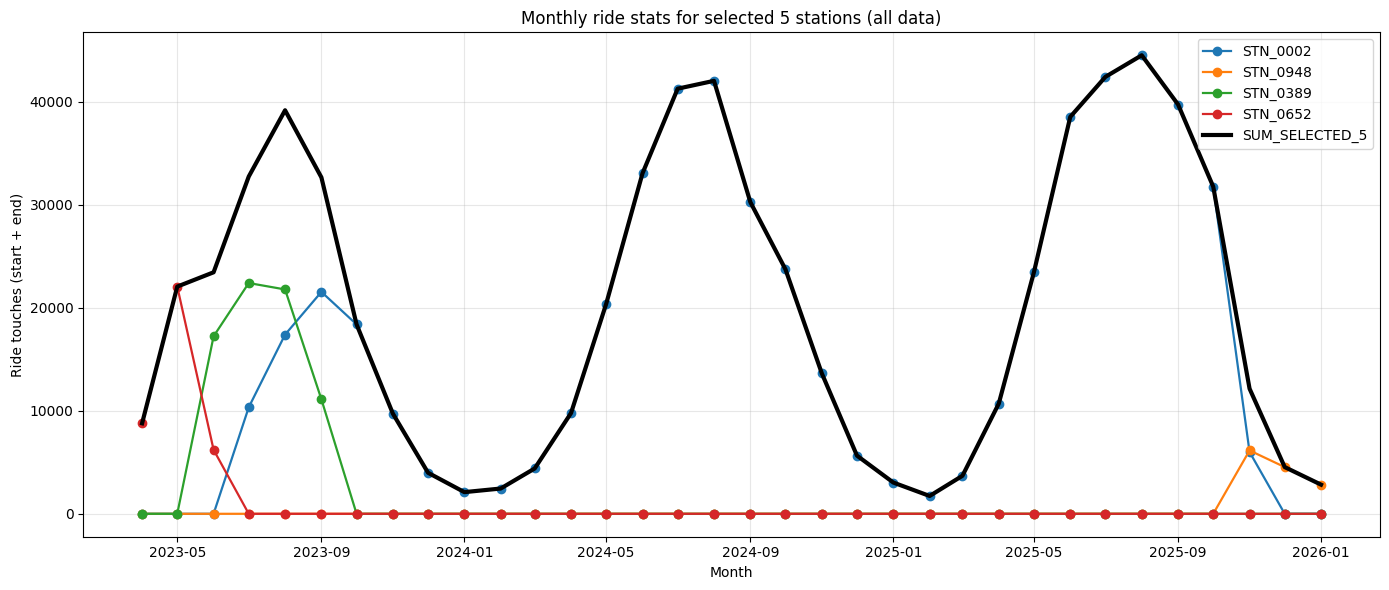

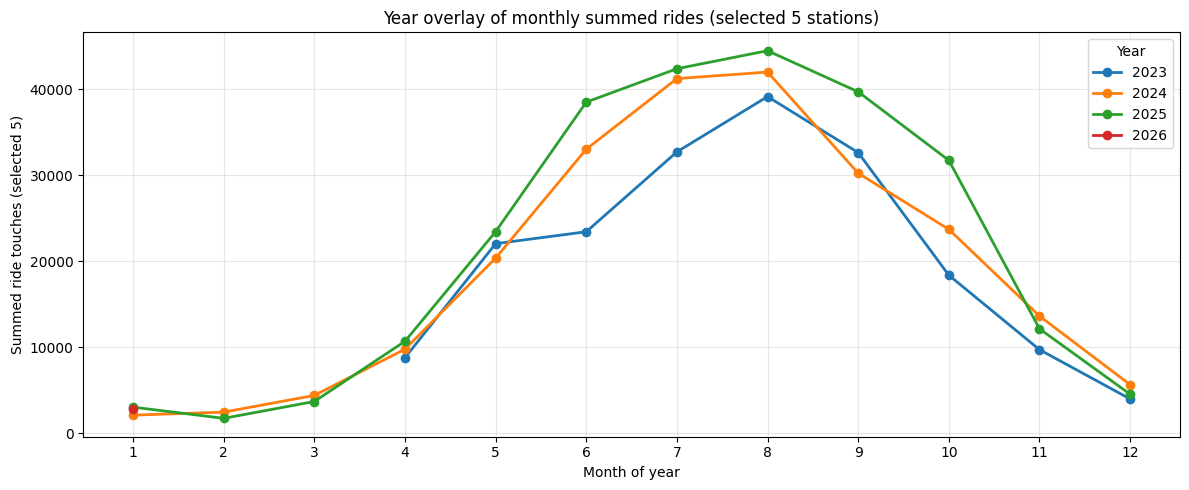

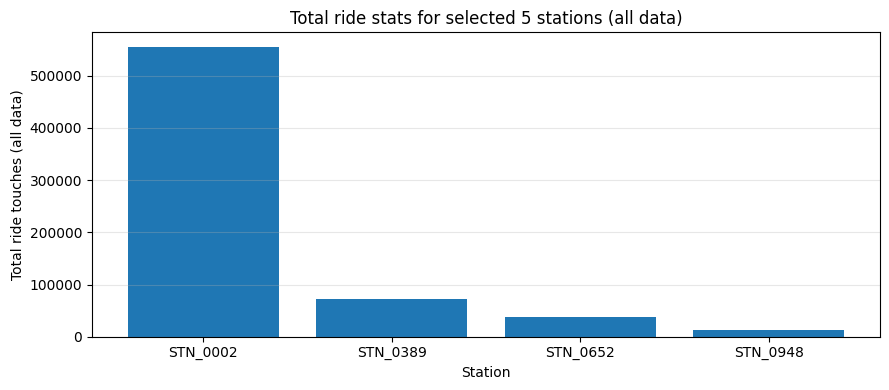

In [108]:
# Task: plot monthly ride stats for 5 stations across all available data (chronological)
import pandas as pd

# Re-run radius lookup frame with current radius_m setting
if "stations_radius_pd" not in globals() or stations_radius_pd.empty:
    stations_radius_pd = stations_radius.toPandas()

# If you already defined your own 5 stations, keep them.
# Example override: selected_station_ids = ["STN_xxxx", ...]
if "selected_station_ids" in globals() and isinstance(selected_station_ids, list) and len(selected_station_ids) == 5:
    station_ids_5 = selected_station_ids
else:
    station_ids_5 = stations_radius_pd.sort_values("distance_m").head(10)["station_id"].tolist()

print("Selected 5 stations:", station_ids_5)

start_all = (
    rides_df
    .filter(F.col("start_canonical_station_id").isin(station_ids_5))
    .select(
        F.col("start_canonical_station_id").alias("station_id"),
        F.date_trunc("month", F.col("start_time_ms")).alias("event_month")
    )
)

end_all = (
    rides_df
    .filter(F.col("end_canonical_station_id").isin(station_ids_5))
    .select(
        F.col("end_canonical_station_id").alias("station_id"),
        F.date_trunc("month", F.col("end_time_ms")).alias("event_month")
    )
)

monthly_all_pd = (
    start_all
    .unionByName(end_all)
    .groupBy("station_id", "event_month")
    .agg(F.count("*").alias("touch_trips"))
    .orderBy("event_month", "station_id")
    .toPandas()
)

if monthly_all_pd.empty:
    raise RuntimeError("No rides found for selected stations in the available dataset.")

monthly_all_pd["event_month"] = pd.to_datetime(monthly_all_pd["event_month"])

# Ensure every month exists per station for clean chronological lines
min_month = monthly_all_pd["event_month"].min()
max_month = monthly_all_pd["event_month"].max()
all_months = pd.date_range(min_month, max_month, freq="MS")
grid = pd.MultiIndex.from_product([station_ids_5, all_months], names=["station_id", "event_month"]).to_frame(index=False)

monthly_all_pd = (
    grid
    .merge(monthly_all_pd, on=["station_id", "event_month"], how="left")
    .fillna({"touch_trips": 0})
)
monthly_all_pd["touch_trips"] = monthly_all_pd["touch_trips"].astype(int)

# Sum across selected stations for each month
monthly_sum_pd = (
    monthly_all_pd
    .groupby("event_month", as_index=False)["touch_trips"]
    .sum()
    .rename(columns={"touch_trips": "sum_touch_trips"})
)

station_total_pd = (
    monthly_all_pd
    .groupby("station_id", as_index=False)["touch_trips"]
    .sum()
    .rename(columns={"touch_trips": "total_touch_trips_all_data"})
    .sort_values("total_touch_trips_all_data", ascending=False)
)

print("\nTotals across all available data (start+end touches):")
print(station_total_pd)
print("\nTotal across selected stations (all data):", int(monthly_sum_pd["sum_touch_trips"].sum()))

# Plot monthly chronological trends per station + sum line
plt.figure(figsize=(14, 6))
for sid in station_ids_5:
    s = monthly_all_pd[monthly_all_pd["station_id"] == sid].sort_values("event_month")
    plt.plot(s["event_month"], s["touch_trips"], marker="o", linewidth=1.6, label=sid)

plt.plot(
    monthly_sum_pd["event_month"],
    monthly_sum_pd["sum_touch_trips"],
    color="black",
    linewidth=3,
    label="SUM_SELECTED_5"
)

plt.xlabel("Month")
plt.ylabel("Ride touches (start + end)")
plt.title("Monthly ride stats for selected 5 stations (all data)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Overlay by year for the summed series
overlay_pd = monthly_sum_pd.copy()
overlay_pd["year"] = overlay_pd["event_month"].dt.year
overlay_pd["month_num"] = overlay_pd["event_month"].dt.month

plt.figure(figsize=(12, 5))
for y in sorted(overlay_pd["year"].unique()):
    sy = overlay_pd[overlay_pd["year"] == y].sort_values("month_num")
    plt.plot(sy["month_num"], sy["sum_touch_trips"], marker="o", linewidth=2, label=str(y))

plt.xticks(range(1, 13))
plt.xlabel("Month of year")
plt.ylabel("Summed ride touches (selected 5)")
plt.title("Year overlay of monthly summed rides (selected 5 stations)")
plt.grid(alpha=0.3)
plt.legend(title="Year")
plt.tight_layout()
plt.show()

# Plot total bars across all data
plt.figure(figsize=(9, 4))
plt.bar(station_total_pd["station_id"], station_total_pd["total_touch_trips_all_data"])
plt.xlabel("Station")
plt.ylabel("Total ride touches (all data)")
plt.title("Total ride stats for selected 5 stations (all data)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [110]:
# District Analysis for STN_0002
import pandas as pd
from pyspark.sql import functions as F

# Get districts for all stations (from both start and end positions)
start_districts = rides_df.select(
    F.col("start_canonical_station_id").alias("station_id"),
    F.col("start_station_district").alias("district")
).dropDuplicates()

end_districts = rides_df.select(
    F.col("end_canonical_station_id").alias("station_id"),
    F.col("end_station_district").alias("district")
).dropDuplicates()

# Combine and get primary district for each station (prefer start over end)
all_districts = start_districts.union(end_districts).dropDuplicates(["station_id"])
print("All districts found:")
all_districts_pd = all_districts.toPandas()
print(all_districts_pd.sort_values("station_id"))

# Get district for target station STN_0002
target_district = all_districts_pd[all_districts_pd["station_id"] == "STN_0002"]
print(f"\n{'='*60}")
print(f"TARGET STATION: STN_0002")
print(f"DISTRICT: {target_district['district'].values[0] if len(target_district) > 0 else 'Not found'}")
print(f"{'='*60}")

# Count stations per district
stations_per_district = all_districts_pd.groupby("district")["station_id"].nunique().sort_values(ascending=False)
print(f"\nStations per district:")
print(stations_per_district)

# Get district for each of our 5 selected stations
print(f"\nOur 5 selected stations and their districts:")
for sid in station_ids_5:
    dist = all_districts_pd[all_districts_pd["station_id"] == sid]["district"]
    if len(dist) > 0:
        print(f"  {sid}: {dist.values[0]}")
    else:
        print(f"  {sid}: Not found")

# General analysis per district
print(f"\n{'='*60}")
print("GENERAL ANALYSIS BY DISTRICT")
print(f"{'='*60}")

# Join rides data with district info
rides_with_district_start = rides_df.join(
    start_districts, 
    rides_df["start_canonical_station_id"] == start_districts["station_id"],
    "left"
).select(
    F.col("start_canonical_station_id").alias("station_id"),
    F.col("district").alias("station_district"),
    "start_time_ms",
    "ride_year"
)

# Aggregate by district
district_stats = rides_with_district_start.groupBy("station_district").agg(
    F.count("*").alias("total_trips"),
    F.countDistinct("station_id").alias("unique_stations"),
    F.min("ride_year").alias("first_year"),
    F.max("ride_year").alias("last_year"),
    F.countDistinct("ride_year").alias("years_active")
).orderBy(F.desc("total_trips"))

district_stats_pd = district_stats.toPandas()
print(district_stats_pd.to_string())

# More detailed breakdown by district
print(f"\n{'='*60}")
print("DETAILED BREAKDOWN BY DISTRICT")
print(f"{'='*60}")

for _, row in district_stats_pd.iterrows():
    district = row["station_district"]
    print(f"\nDistrict: {district}")
    print(f"  Total trips: {int(row['total_trips']):,}")
    print(f"  Unique stations: {int(row['unique_stations'])}")
    print(f"  Data years: {int(row['first_year'])}-{int(row['last_year'])} (active {int(row['years_active'])} years)")
    print(f"  Avg trips per station: {int(row['total_trips']) / int(row['unique_stations']):,.0f}")
    
    # Get stations in this district
    stations_in_district = all_districts_pd[all_districts_pd["district"] == district]["station_id"].tolist()
    print(f"  Stations: {', '.join(sorted(stations_in_district))}")


All districts found:


     station_id                                  district
1      STN_0001                     Le Plateau-Mont-Royal
2      STN_0002                     Le Plateau-Mont-Royal
3      STN_0003                     Le Plateau-Mont-Royal
4      STN_0004                     Le Plateau-Mont-Royal
5      STN_0005                     Le Plateau-Mont-Royal
...         ...                                       ...
1553   STN_1553                                     Laval
1554   STN_1554     Côte-des-Neiges - Notre-Dame-de-Grâce
1555   STN_1555                     Le Plateau-Mont-Royal
1556   STN_1556  Villeray - Saint-Michel - Parc-Extension
0           NaN                                       NaN

[1557 rows x 2 columns]

TARGET STATION: STN_0002
DISTRICT: Le Plateau-Mont-Royal

Stations per district:
district
Ville-Marie                                   277
Le Plateau-Mont-Royal                         231
Rosemont - La Petite-Patrie                   146
Laval                                 

                              station_district  total_trips  unique_stations  first_year  last_year  years_active
0                        Le Plateau-Mont-Royal     13275849              234        2023       2026             4
1                                  Ville-Marie     10048667              282        2023       2026             4
2                  Rosemont - La Petite-Patrie      4987267              148        2023       2026             4
3                                 Le Sud-Ouest      2831058              106        2023       2026             4
4         Villeray—Saint-Michel—Parc-Extension      1910941               86        2023       2026             4
5     Villeray - Saint-Michel - Parc-Extension      1657933               58        2023       2026             4
6              Mercier - Hochelaga-Maisonneuve      1618671               76        2023       2026             4
7        Côte-des-Neiges - Notre-Dame-de-Grâce      1557815               94        2023

In [111]:
# Summary: District Analysis Results
print("="*70)
print("DISTRICT SUMMARY FOR STN_0002 ANALYSIS")
print("="*70)

# Show only unique districts and summary
print("\nSTN_0002 District:", target_district["district"].values[0] if len(target_district) > 0 else "Not found")
print(f"Total unique districts in dataset: {len(stations_per_district)}")
print(f"\nTop 10 districts by station count:")
print(stations_per_district.head(10).to_string())

# Our 5 selected stations
print(f"\n{'='*70}")
print("OUR 5 SELECTED STATIONS BY DISTRICT:")
print('='*70)
station_district_map = {}
for sid in station_ids_5:
    dist = all_districts_pd[all_districts_pd["station_id"] == sid]["district"]
    if len(dist) > 0:
        d = dist.values[0]
        station_district_map[sid] = d
        print(f"  {sid}: {d}")

# Show which districts our 5 stations are in
unique_districts_in_our_selection = set(station_district_map.values())
print(f"\nOur 5 stations span {len(unique_districts_in_our_selection)} different district(s):")
for d in sorted(unique_districts_in_our_selection):
    stations_in_d = [s for s, dist in station_district_map.items() if dist == d]
    print(f"  {d}: {', '.join(stations_in_d)}")

print(f"\n{'='*70}")
print("DISTRICT STATISTICS:")
print('='*70)
print(district_stats_pd[["station_district", "total_trips", "unique_stations", "first_year", "last_year"]].to_string(index=False))


DISTRICT SUMMARY FOR STN_0002 ANALYSIS

STN_0002 District: Le Plateau-Mont-Royal
Total unique districts in dataset: 33

Top 10 districts by station count:
district
Ville-Marie                              277
Le Plateau-Mont-Royal                    231
Rosemont - La Petite-Patrie              146
Laval                                    115
Le Sud-Ouest                             106
Côte-des-Neiges - Notre-Dame-de-Grâce     95
Villeray—Saint-Michel—Parc-Extension      85
Mercier - Hochelaga-Maisonneuve           76
Longueuil                                 63
Ahuntsic-Cartierville                     56

OUR 5 SELECTED STATIONS BY DISTRICT:
  STN_0002: Le Plateau-Mont-Royal
  STN_0948: Le Plateau-Mont-Royal
  STN_0389: Le Plateau-Mont-Royal
  STN_0652: Le Plateau-Mont-Royal

Our 5 stations span 1 different district(s):
  Le Plateau-Mont-Royal: STN_0002, STN_0948, STN_0389, STN_0652

DISTRICT STATISTICS:
                          station_district  total_trips  unique_stations  first_

In [112]:
# Ultra-concise district summary
import codecs

target_dist = target_district["district"].values[0] if len(target_district) > 0 else "Unknown"

output = f"""
{'='*70}
DISTRICT ANALYSIS - KEY FINDINGS
{'='*70}

TARGET STATION: STN_0002
District: {target_dist}

OUR 5 SELECTED STATIONS:
"""

for sid in sorted(station_ids_5):
    dist = station_district_map.get(sid, "Unknown")
    output += f"  {sid}: {dist}\n"

output += f"""
DISTRICT BREAKDOWN - Total Trips by District:
{'-'*70}
"""

# Get top districts by trips
top_districts = district_stats_pd.nsmallest(10, 'total_trips', keep='all')
for idx, row in top_districts.iterrows():
    dist_name = row["station_district"]
    trips = int(row["total_trips"])
    n_stations = int(row["unique_stations"])
    output += f"{dist_name:30s} | Trips: {trips:>10,} | Stations: {n_stations:>3}\n"

print(output)



DISTRICT ANALYSIS - KEY FINDINGS

TARGET STATION: STN_0002
District: Le Plateau-Mont-Royal

OUR 5 SELECTED STATIONS:
  STN_0002: Le Plateau-Mont-Royal
  STN_0389: Le Plateau-Mont-Royal
  STN_0652: Le Plateau-Mont-Royal
  STN_0948: Le Plateau-Mont-Royal

DISTRICT BREAKDOWN - Total Trips by District:
----------------------------------------------------------------------
Le Vieux-Longueuil             | Trips:         88 | Stations:   1
LÎle-Bizard - Sainte-Geneviève | Trips:        274 | Stations:   1
Saint-Eustache                 | Trips:        824 | Stations:   8
Deux-Montagnes                 | Trips:        855 | Stations:   5
Sainte-Julie                   | Trips:      1,610 | Stations:   5
Saint-Lambert                  | Trips:      2,287 | Stations:   3
Terrebonne                     | Trips:      3,826 | Stations:   3
Pierrefonds - Roxboro          | Trips:      4,453 | Stations:   9
Montréal-Est                   | Trips:      6,116 | Stations:   4
Boucherville             

In [113]:
# Complete District Statistics (all districts, sorted by trips)
print("\n" + "="*70)
print("COMPLETE DISTRICT STATISTICS (Sorted by Total Trips)")
print("="*70)
print(f"{'Rank':<5} {'District':<35} {'Trips':>12} {'Stations':>8} {'Avg/Stn':>10}")
print("-"*70)

district_stats_sorted = district_stats_pd.sort_values("total_trips", ascending=False).reset_index(drop=True)

for idx, row in district_stats_sorted.iterrows():
    dist_name = row["station_district"]
    trips = int(row["total_trips"])
    n_stations = int(row["unique_stations"])
    avg_per_station = int(trips / n_stations) if n_stations > 0 else 0
    
    # Highlight Le Plateau-Mont-Royal
    marker = " ← TARGET" if dist_name == target_dist else ""
    print(f"{idx+1:<5} {dist_name:<35} {trips:>12,} {n_stations:>8} {avg_per_station:>10,}{marker}")

print("\n" + "="*70)
print("KEY METRICS:")
print("="*70)
print(f"Le Plateau-Mont-Royal rank: #{district_stats_sorted[district_stats_sorted['station_district'] == target_dist].index[0] + 1 if len(district_stats_sorted[district_stats_sorted['station_district'] == target_dist]) > 0 else 'N/A'}")
print(f"Total districts: {len(district_stats_pd)}")
print(f"Total trips across all districts: {int(district_stats_pd['total_trips'].sum()):,}")
print(f"Total unique stations across all districts: {int(district_stats_pd['unique_stations'].sum())}")



COMPLETE DISTRICT STATISTICS (Sorted by Total Trips)
Rank  District                                   Trips Stations    Avg/Stn
----------------------------------------------------------------------
1     Le Plateau-Mont-Royal                 13,275,849      234     56,734 ← TARGET
2     Ville-Marie                           10,048,667      282     35,633
3     Rosemont - La Petite-Patrie            4,987,267      148     33,697
4     Le Sud-Ouest                           2,831,058      106     26,708
5     Villeray—Saint-Michel—Parc-Extension    1,910,941       86     22,220
6     Villeray - Saint-Michel - Parc-Extension    1,657,933       58     28,585
7     Mercier - Hochelaga-Maisonneuve        1,618,671       76     21,298
8     Côte-des-Neiges - Notre-Dame-de-Grâce    1,557,815       94     16,572
9     Verdun                                   927,938       48     19,332
10    Outremont                                715,968       32     22,374
11    Ahuntsic-Cartierville      

In [1]:
# Objective:
# Identify district(s) associated with station IDs STN_0001 and STN_0002 from rides data.
# Plan:
# 1) Extract station->district pairs from both start and end ride fields.
# 2) Filter to the two target station IDs.
# 3) Show distinct districts observed per station.

from pyspark.sql import functions as F

target_ids = ["STN_0001", "STN_0002", "STN_0003", "STN_0004"]

start_pairs = rides_df.select(
    F.col("start_canonical_station_id").alias("station_id"),
    F.col("start_station_district").alias("district"),
    F.lit("start").alias("source")
)

end_pairs = rides_df.select(
    F.col("end_canonical_station_id").alias("station_id"),
    F.col("end_station_district").alias("district"),
    F.lit("end").alias("source")
)

station_districts = (
    start_pairs.unionByName(end_pairs)
    .filter(F.col("station_id").isin(target_ids))
    .filter(F.col("district").isNotNull() & (F.trim(F.col("district")) != ""))
    .dropDuplicates(["station_id", "district", "source"])
    .orderBy("station_id", "district", "source")
)

print("District records for STN_0001 and STN_0002:")
station_districts.show(truncate=False)

summary = (
    station_districts.groupBy("station_id")
    .agg(F.sort_array(F.collect_set("district")).alias("districts"))
    .orderBy("station_id")
)

print("\nDistinct district(s) per station:")
summary.show(truncate=False)

NameError: name 'rides_df' is not defined